<a href="https://colab.research.google.com/github/shanusushmita/CS4973-Applied-Multilingual-Systems/blob/main/Code_Switching_Analysis_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating mock data at structured_dialogues.jsonl...
Mock data generated successfully.

Data loaded successfully. Total turns: 6

--- Key Metrics Summary ---
Total Turns Analyzed: 6
Mixed Utterance Ratio (MUR): 0.6667 (4 out of 6 turns are mixed)
Average Word-Level CSI: 0.2764
Average Shannon Entropy: 0.5714 bits

--- Example Turn Analysis ---
   turn_id                                               text  is_mixed  \
0        1     I need to review the document for the meeting.         0   
1        2                  Can we schedule it for el jueves?         1   
2        3                The main thing is el budget, right?         1   
3        4                Yo no tengo problema con esa fecha.         0   
4        5  I will make the changes, and then tu puedes re...         1   

        CSI   Entropy  
0  0.000000 -0.000000  
1  0.200000  0.918296  
2  0.333333  0.591673  
3  0.000000 -0.000000  
4  0.125000  0.918296  

Generating visualizations...


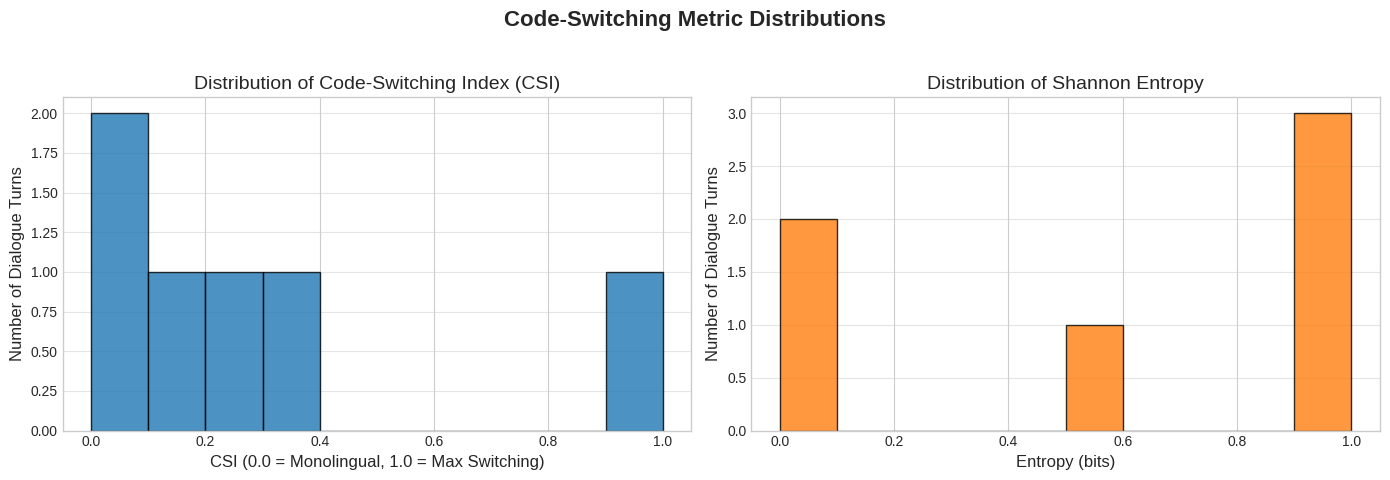


Analysis complete. Check the generated plots and summary statistics.


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# --- 0. Mock Data Generation (To be replaced by your real data loading) ---
FILEPATH = 'structured_dialogues.jsonl'

def generate_mock_data(filepath):
    """Generates a mock structured_dialogues.jsonl file."""
    print(f"Generating mock data at {filepath}...")
    mock_turns = [
        # Turn 1: Pure L1 (Low CSI, Low Entropy)
        {'turn_id': 1, 'text': "I need to review the document for the meeting.",
         'language_tags': ['L1', 'L1', 'L1', 'L1', 'L1', 'L1', 'L1', 'L1']},

        # Turn 2: Mixed (L1/L2) (High CSI, High Entropy, MUR = 1)
        {'turn_id': 2, 'text': "Can we schedule it for el jueves?",
         'language_tags': ['L1', 'L1', 'L1', 'L1', 'L2', 'L2']},

        # Turn 3: Intrasentential Mixing (Highest CSI, High Entropy, MUR = 1)
        {'turn_id': 3, 'text': "The main thing is el budget, right?",
         'language_tags': ['L1', 'L1', 'L1', 'L1', 'L2', 'L1', 'L1']},

        # Turn 4: Pure L2 (Low CSI, Low Entropy)
        {'turn_id': 4, 'text': "Yo no tengo problema con esa fecha.",
         'language_tags': ['L2', 'L2', 'L2', 'L2', 'L2', 'L2']},

        # Turn 5: Dense Code-Switching (Very High CSI/Entropy, MUR = 1)
        {'turn_id': 5, 'text': "I will make the changes, and then tu puedes revisar.",
         'language_tags': ['L1', 'L1', 'L1', 'L1', 'L1', 'L1', 'L2', 'L2', 'L2']},

        # Turn 6: Short Mixed Utterance (High CSI, High Entropy, MUR = 1)
        {'turn_id': 6, 'text': "Okay, perfecto.",
         'language_tags': ['L1', 'L2']},
    ]

    with open(filepath, 'w', encoding='utf-8') as f:
        for turn in mock_turns:
            f.write(json.dumps(turn) + '\n')
    print("Mock data generated successfully.")

# --- 1. Load Data ---

def load_data(filepath):
    """Loads the structured_dialogues.jsonl file into a DataFrame."""
    try:
        df = pd.read_json(filepath, lines=True)
        # Ensure 'language_tags' is a list of strings
        df['language_tags'] = df['language_tags'].apply(lambda x: [str(tag) for tag in x])
        print(f"\nData loaded successfully. Total turns: {len(df)}")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}. Please ensure the file exists or run the mock data generation.")
        return pd.DataFrame()

# --- 2. Calculate Mixed Utterance Ratio (MUR) ---

def calculate_mur(tags):
    """
    Calculates if an utterance is 'mixed' by checking for the presence of multiple unique language tags.
    Returns 1 for mixed, 0 for monolingual.
    """
    if not tags:
        return 0
    # Filter out empty or non-language tags if necessary, but here we assume the mock data is clean
    unique_languages = set(tags)
    return 1 if len(unique_languages) > 1 else 0

# --- 3. Calculate Code-Switching Index (CSI) ---

def calculate_csi(tags):
    """
    Calculates the Code-Switching Index (CSI) for a single dialogue turn.
    CSI = (Number of Switch Points) / (Total Number of Possible Switch Points)
    Switch Point is defined as L_i != L_{i+1}.
    """
    num_tokens = len(tags)
    if num_tokens < 2:
        return 0.0

    switch_points = 0
    # Iterate through consecutive pairs of tags
    for i in range(num_tokens - 1):
        if tags[i] != tags[i+1]:
            switch_points += 1

    # Total possible switch points is num_tokens - 1
    return switch_points / (num_tokens - 1)

# --- 4. Calculate Shannon Entropy (Challenge) ---

def calculate_entropy(tags):
    """
    Calculates the Shannon Entropy (H) of language distribution in a turn.
    H = - sum(p_i * log2(p_i))
    A higher value indicates a more balanced distribution of languages.
    """
    num_tokens = len(tags)
    if num_tokens == 0:
        return 0.0

    # Count frequencies of each language
    language_counts = pd.Series(tags).value_counts()

    # Calculate probabilities (p_i)
    probabilities = language_counts / num_tokens

    # Calculate Shannon Entropy
    # H = - sum(p_i * log2(p_i))
    entropy = -np.sum(probabilities * np.log2(probabilities))

    return entropy

# --- 5. Visualization (Challenge) ---

def plot_distributions(df):
    """Creates visualizations for CSI and Entropy distributions."""
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: CSI Distribution
    axes[0].hist(df['CSI'], bins=10, color='#1f77b4', edgecolor='black', alpha=0.8)
    axes[0].set_title('Distribution of Code-Switching Index (CSI)', fontsize=14)
    axes[0].set_xlabel('CSI (0.0 = Monolingual, 1.0 = Max Switching)', fontsize=12)
    axes[0].set_ylabel('Number of Dialogue Turns', fontsize=12)
    axes[0].grid(axis='y', alpha=0.5)

    # Plot 2: Shannon Entropy Distribution
    axes[1].hist(df['Entropy'], bins=10, color='#ff7f0e', edgecolor='black', alpha=0.8)
    axes[1].set_title('Distribution of Shannon Entropy', fontsize=14)
    axes[1].set_xlabel('Entropy (bits)', fontsize=12)
    axes[1].set_ylabel('Number of Dialogue Turns', fontsize=12)
    axes[1].grid(axis='y', alpha=0.5)

    plt.suptitle('Code-Switching Metric Distributions', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# --- Main Execution ---

if __name__ == "__main__":

    # 0. Generate mock data (Remove this line if your file already exists)
    generate_mock_data(FILEPATH)

    # 1. Load the data
    dialogue_df = load_data(FILEPATH)

    if dialogue_df.empty:
        print("Analysis terminated due to empty DataFrame.")
    else:
        # 2 & 3 & 4. Calculate Metrics
        dialogue_df['is_mixed'] = dialogue_df['language_tags'].apply(calculate_mur)
        dialogue_df['CSI'] = dialogue_df['language_tags'].apply(calculate_csi)
        dialogue_df['Entropy'] = dialogue_df['language_tags'].apply(calculate_entropy)

        # Calculate Group Metrics
        total_turns = len(dialogue_df)
        mixed_utterance_ratio = dialogue_df['is_mixed'].mean()
        average_csi = dialogue_df['CSI'].mean()
        average_entropy = dialogue_df['Entropy'].mean()

        print("\n--- Key Metrics Summary ---")
        print(f"Total Turns Analyzed: {total_turns}")
        print(f"Mixed Utterance Ratio (MUR): {mixed_utterance_ratio:.4f} "
              f"({dialogue_df['is_mixed'].sum()} out of {total_turns} turns are mixed)")
        print(f"Average Word-Level CSI: {average_csi:.4f}")
        print(f"Average Shannon Entropy: {average_entropy:.4f} bits")
        print("\n--- Example Turn Analysis ---")
        print(dialogue_df[['turn_id', 'text', 'is_mixed', 'CSI', 'Entropy']].head())

        # 5. Run Visualization
        print("\nGenerating visualizations...")
        plot_distributions(dialogue_df)

        print("\nAnalysis complete. Check the generated plots and summary statistics.")